In [5]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print("TF version:", tf.__version__)
print("GPUs verfügbar:", tf.config.list_physical_devices('GPU'))

# ── Load preprocessed data from Notebook 02 ──────────────────
DATA_DIR = Path("../data/processed")

X_train = np.load(DATA_DIR / "X_train.npy")
y_train = np.load(DATA_DIR / "y_train.npy")
X_test  = np.load(DATA_DIR / "X_test.npy")
y_test  = np.load(DATA_DIR / "y_test.npy")

print(f"\nX_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")

# Conv layers expect a channel dimension: (samples, height, width, channels)
X_train = X_train[..., np.newaxis]   # (16340, 128, 32, 1)
X_test  = X_test[..., np.newaxis]

print(f"\nAfter reshape:")
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")

TF version: 2.21.0
GPUs verfügbar: []

X_train: (16340, 128, 32)
X_test:  (10602, 128, 32)

After reshape:
X_train: (16340, 128, 32, 1)
X_test:  (10602, 128, 32, 1)


In [3]:
# That approach wasnt sufficient based on the error reconstruction - normal vs. abnormal was not separated enough 
# Results first run:
# Normal   — mean: 0.00097, std: 0.00017
# Abnormal — mean: 0.00103, std: 0.00017
'''
def build_autoencoder(input_shape=(128, 32, 1)):
    inputs = keras.Input(shape=input_shape)

    # Enocder
    x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(inputs)
    x = layers.MaxPooling2D((2,2), padding="same")(x) # 64x16x32

    x = layers.Conv2D(16, (3, 3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D((2, 2), padding="same")(x) # 32x8x16

    x = layers.Conv2D(8, (3, 3), activation="relu", padding="same")(x)
    encoded = layers.MaxPooling2D((2, 2), padding="same")(x) # 16x4x8 -> Bottleneck is forcing to focus on significant features

    # Decoder
    x = layers.Conv2DTranspose(8, (3, 3), strides=2, activation="relu", padding="same")(encoded)
    x = layers.Conv2DTranspose(16, (3, 3), strides=2, activation="relu", padding="same")(x)
    x = layers.Conv2DTranspose(32, (3, 3), strides=2, activation="relu", padding="same")(x)

    outputs = layers.Conv2D(1, (3, 3), activation="sigmoid", padding="same")(x)

    autoencoder = keras.Model(inputs, outputs, name="conv_autoencoder")
    return autoencoder

autoencoder = build_autoencoder()
autoencoder.summary()
'''

'\ndef build_autoencoder(input_shape=(128, 32, 1)):\n    inputs = keras.Input(shape=input_shape)\n\n    # Enocder\n    x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(inputs)\n    x = layers.MaxPooling2D((2,2), padding="same")(x) # 64x16x32\n\n    x = layers.Conv2D(16, (3, 3), activation="relu", padding="same")(x)\n    x = layers.MaxPooling2D((2, 2), padding="same")(x) # 32x8x16\n\n    x = layers.Conv2D(8, (3, 3), activation="relu", padding="same")(x)\n    encoded = layers.MaxPooling2D((2, 2), padding="same")(x) # 16x4x8 -> Bottleneck is forcing to focus on significant features\n\n    # Decoder\n    x = layers.Conv2DTranspose(8, (3, 3), strides=2, activation="relu", padding="same")(encoded)\n    x = layers.Conv2DTranspose(16, (3, 3), strides=2, activation="relu", padding="same")(x)\n    x = layers.Conv2DTranspose(32, (3, 3), strides=2, activation="relu", padding="same")(x)\n\n    outputs = layers.Conv2D(1, (3, 3), activation="sigmoid", padding="same")(x)\n\n    autoenc

In [6]:
# smaller bottleneck = more prioritization (4 instead of 8 filters)
# added Conv-Layer prior to first pooling layer --> more detailed frequencies before they are smoothed away
# batch normalization --> stabilsed training and recognition of fine patterns

def build_autoencoder_v2(input_shape=(128, 32, 1)):
    inputs = keras.Input(shape=input_shape)

    # ── Encoder ───────────────────────────────────────────────
    x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(x)   # extra Layer
    x = layers.MaxPooling2D((2, 2), padding="same")(x)        # → 64×16×32

    x = layers.Conv2D(16, (3, 3), activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2), padding="same")(x)        # → 32×8×16

    x = layers.Conv2D(8, (3, 3), activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    encoded = layers.MaxPooling2D((2, 2), padding="same")(x)  # → 16×4×8

    # Kleinerer Bottleneck via Dense-Squeeze
    flat = layers.Flatten()(encoded)
    bottleneck = layers.Dense(64, activation="relu", name="bottleneck")(flat)  # erzwungene Kompression!
    x = layers.Dense(16 * 4 * 8, activation="relu")(bottleneck)
    x = layers.Reshape((16, 4, 8))(x)

    # ── Decoder ───────────────────────────────────────────────
    x = layers.Conv2DTranspose(8, (3, 3), strides=2, activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2DTranspose(16, (3, 3), strides=2, activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2DTranspose(32, (3, 3), strides=2, activation="relu", padding="same")(x)
    x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(x)

    outputs = layers.Conv2D(1, (3, 3), activation="sigmoid", padding="same")(x)

    autoencoder = keras.Model(inputs, outputs, name="conv_autoencoder_v2")
    return autoencoder


autoencoder_v2 = build_autoencoder_v2()
autoencoder_v2.summary()

Model: "conv_autoencoder_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 32, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 128, 32, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128, 32, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 128, 32, 32)    │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 64, 16, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 64, 16, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 8, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 8, 8)       │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32, 8, 8)       │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 4, 8)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 64)             │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │        33,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 16, 4, 8)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 32, 8, 8)       │           584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 32, 8, 8)       │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 64, 16, 16)     │         1,168 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 64, 16, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_5              │ (None, 128, 32, 32)    │         4,640 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 128, 32, 32)    │         9,24

 Total params: 97,713 (381.69 KB)

 Trainable params: 97,553 (381.07 KB)

 Non-trainable params: 160 (640.00 B)

In [5]:
# Cell 3 - Compile the model
'''
autoencoder.compile(optimizer="adam", loss="mse")

print("Model compiled. Ready for training.")
'''

'\nautoencoder.compile(optimizer="adam", loss="mse")\n\nprint("Model compiled. Ready for training.")\n'

In [ ]:
# Cell 3 - Compile and train model based on new architecture

autoencoder_v2.compile(optimizer="adam", loss="mse")

early_stop_v2 = EarlyStopping(
    monitor="val_loss",
    patience=7,          
    restore_best_weights=True
)

history_v2 = autoencoder_v2.fit(
    X_train, X_train,
    epochs=60,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop_v2],
    verbose=1
)

In [9]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor = "val_loss",
    patience = 5,
    restore_best_weights = True
)

history = autoencoder_v2.fit(
    X_train, X_train,
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    callbacks=[],
    verbose=1
)

Epoch 1/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 69s 294ms/step - loss: 0.0046 - val_loss: 0.0633
Epoch 2/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 66s 288ms/step - loss: 0.0018 - val_loss: 0.0462
Epoch 3/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 66s 287ms/step - loss: 0.0016 - val_loss: 0.0035
Epoch 4/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 66s 287ms/step - loss: 0.0016 - val_loss: 0.0019
Epoch 5/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 66s 288ms/step - loss: 0.0015 - val_loss: 0.0019
Epoch 6/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 63s 274ms/step - loss: 0.0015 - val_loss: 0.0015
Epoch 7/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 62s 269ms/step - loss: 0.0015 - val_loss: 0.0016
Epoch 8/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 62s 267ms/step - loss: 0.0015 - val_loss: 0.0020
Epoch 9/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 61s 267ms/step - loss: 0.0014 - val_loss: 0.0015
Epoch 10/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 61s 266ms/step - loss: 0.0014 - val_loss: 0.0015
Epoch 11/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 64s 276ms/step - loss: 0.0014 - val_loss: 0.0018
Epoch 12/50
230/230

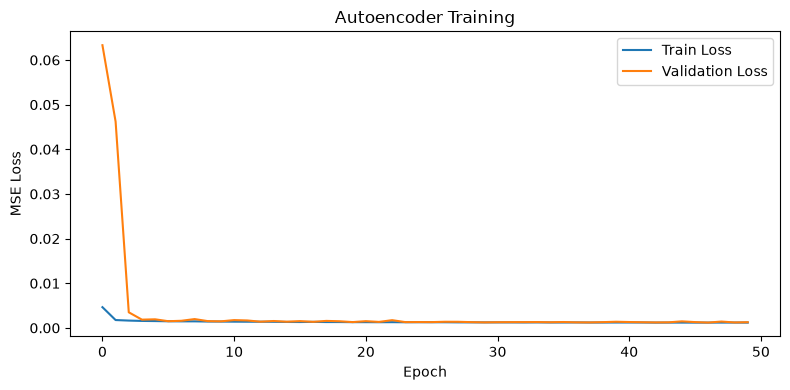

In [10]:
# Cell 5 - Trainings-Verlauf visualisieren

plt.figure(figsize=(8, 4))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Autoencoder Training")
plt.legend()
plt.tight_layout()
plt.savefig("training_history.png", dpi=150)
plt.show()

In [11]:
# Cell 6 - Reconstruction Error on TEST-Set

X_test_pred = autoencoder_v2.predict(X_test, batch_size=64, verbose=1)

# Mean Squared Error PRO SAMPLE (nicht über den ganzen Batch gemittelt!)
reconstruction_errors = np.mean(
    np.square(X_test - X_test_pred), axis=(1, 2, 3)
)

print(f"Reconstruction errors shape: {reconstruction_errors.shape}")
print(f"Min: {reconstruction_errors.min():.5f}")
print(f"Max: {reconstruction_errors.max():.5f}")

166/166 ━━━━━━━━━━━━━━━━━━━━ 10s 60ms/step
Reconstruction errors shape: (10602,)
Min: 0.00096
Max: 0.00914


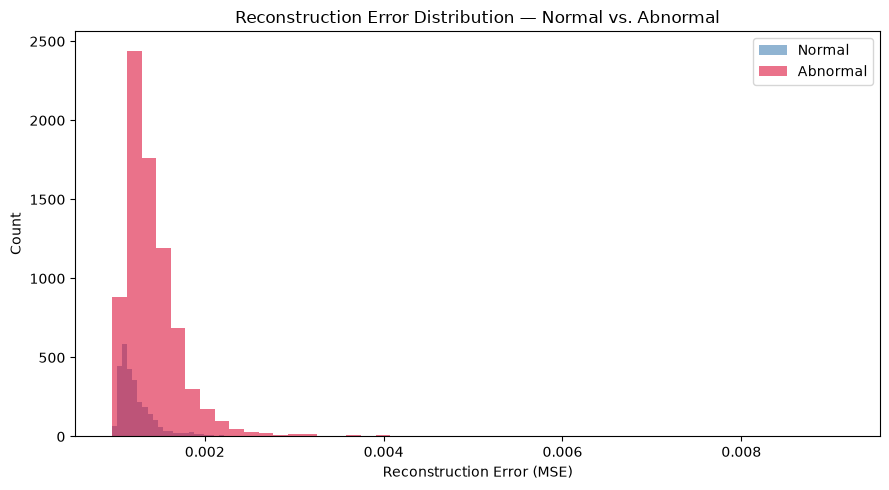

Normal   — mean: 0.00126, std: 0.00029
Abnormal — mean: 0.00143, std: 0.00041


In [12]:
# Cell 7 - Error Distribution: normal vs. abnormal

errors_normal   = reconstruction_errors[y_test == 0]
errors_abnormal = reconstruction_errors[y_test == 1]

plt.figure(figsize=(9, 5))
plt.hist(errors_normal, bins=50, alpha=0.6, label="Normal", color="steelblue")
plt.hist(errors_abnormal, bins=50, alpha=0.6, label="Abnormal", color="crimson")
plt.xlabel("Reconstruction Error (MSE)")
plt.ylabel("Count")
plt.title("Reconstruction Error Distribution — Normal vs. Abnormal")
plt.legend()
plt.tight_layout()
plt.savefig("reconstruction_error_distribution.png", dpi=150)
plt.show()

print(f"Normal   — mean: {errors_normal.mean():.5f}, std: {errors_normal.std():.5f}")
print(f"Abnormal — mean: {errors_abnormal.mean():.5f}, std: {errors_abnormal.std():.5f}")

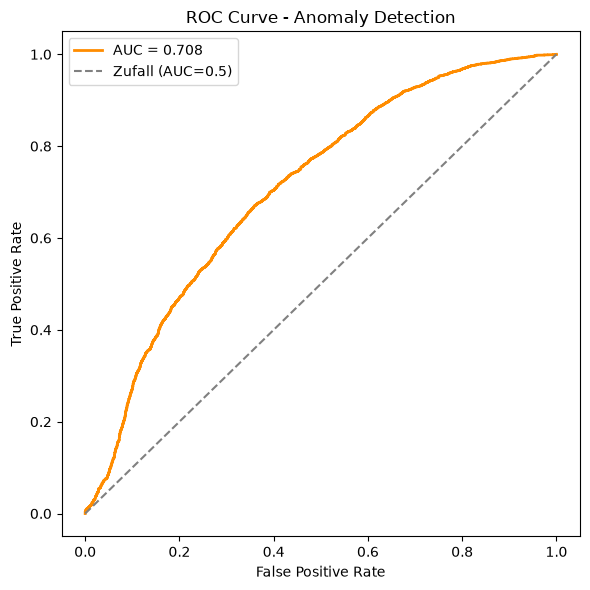

AUC Score: 0.7079


In [13]:
# Cell 8 - ROC Curve and AUC Score

from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, threshold = roc_curve(y_test, reconstruction_errors)
auc_score = roc_auc_score(y_test, reconstruction_errors)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}", color="darkorange", linewidth=2)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Zufall (AUC=0.5)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Anomaly Detection")
plt.legend()
plt.tight_layout()
plt.savefig("roc_curve.png", dpi=150)
plt.show()

print(f"AUC Score: {auc_score:.4f}")